In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
#rom google.colab import drive
#drive.mount('/content/drive')

Reptile meta-learning (Nichol et al., 2018) for 20-way 1-shot character recognition on Omniglot. A shared initialization $\theta$ is trained across episodic tasks so it can adapt to any new 20-class problem from a single example per class.

Each episode samples 20 unseen characters, runs a short SGD inner loop on 1 support image per class, then updates $\theta$ toward the adapted weights. At evaluation time the model adapts using 50 inner steps and is tested on held-out query images.

## Imports

In [3]:
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from torchvision import transforms
import torch.optim as optim
import copy

## Algorithm Overview

**Data representation.** Each Omniglot character (alphabet × glyph × rotation) is an independent class. Rotations (0°, 90°, 180°, 270°) are registered as distinct classes, expanding the class pool fourfold.

**Episode structure (20-way, 1-shot).**

| Split | Images | Labels |
|---|---|---|
| Support | $20 \times 1 = 20$ | $Y_{sup} \in \{0,\ldots,19\}$ |
| Query | $20 \times N_{q}$ | $Y_{qry} \in \{0,\ldots,19\}$ |

**Reptile update.** For each episode:

1. Clone meta-parameters: $W \leftarrow \theta$
2. Inner loop — $k$ SGD steps on the support set:
$$W \leftarrow W - \alpha \, \nabla_W \, \mathcal{L}_{CE}(f_W(X_{sup}),\, Y_{sup})$$
3. Outer update — interpolate toward adapted weights:
$$\theta \leftarrow \theta + \varepsilon\,(W - \theta)$$

$\varepsilon$ is cosine-annealed from 1.0 to 0 over training. The *train-shots trick* (10 support images per class during meta-training vs. 1 at test time) follows the original OpenAI implementation.

## Dataset

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Preprocessing

Images are resized to 28 × 28, converted to single-channel tensors, colour-inverted ($x \leftarrow 1 - x$, so strokes are bright on a dark field), and standardised to zero mean and unit variance.

In [5]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Normalize((0.5,), (0.5,))
])

In [6]:
import kagglehub
import os

path = kagglehub.dataset_download("watesoyan/omniglot")
train_root = os.path.join(path, "images_background")
test_root  = os.path.join(path, "images_evaluation")

In [7]:
import kagglehub
import os


path = kagglehub.dataset_download("watesoyan/omniglot")

print("Path to dataset files:", path)


train_root = os.path.join(path, 'images_background')
test_root = os.path.join(path, 'images_evaluation')

print(f"Train root: {train_root}")
print(f"Test root: {test_root}")

Path to dataset files: /home/sorana/.cache/kagglehub/datasets/watesoyan/omniglot/versions/1
Train root: /home/sorana/.cache/kagglehub/datasets/watesoyan/omniglot/versions/1/images_background
Test root: /home/sorana/.cache/kagglehub/datasets/watesoyan/omniglot/versions/1/images_evaluation


In [8]:
import kagglehub
path = kagglehub.dataset_download("watesoyan/omniglot")

In [9]:
import os

def count_images(root_dir):
    count = 0
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)

        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)

            if not os.path.isdir(character_path):
                continue

            count += len(os.listdir(character_path))

    return count


print("Train Samples:", count_images(train_root))
print("Test Samples:", count_images(test_root))

Train Samples: 19280
Test Samples: 13180


### Class Dictionary & Meta-Splits

`build_class_dict` maps each `alphabet/character/rotN` key to a list of preprocessed image tensors. Rotations are treated as separate classes, giving 4 × the base class count.

Background classes are shuffled and split 80/20:

- **Meta-train (80%)** — inner-loop adaptation and outer-loop updates  
- **Meta-val (20%)** — hyperparameter selection and early stopping  
- **Meta-test** — the separate `images_evaluation` split; never seen during training

In [10]:
import os
import random
from PIL import Image
from torchvision.transforms import functional as TF

def build_class_dict(root_dir, transform):
    class_dict = {}

    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            original_images = []
            for img_name in os.listdir(character_path):
                img_path = os.path.join(character_path, img_name)
                if not os.path.isfile(img_path):
                    continue

                image = Image.open(img_path).convert("L")
                image_tensor = transform(image)
                original_images.append(image_tensor)

            # Register each rotation as a separate class
            for angle in [0, 90, 180, 270]:
                rotated = [TF.rotate(img, angle) for img in original_images]
                class_dict[f"{alphabet}/{character}/rot{angle}"] = rotated

    return class_dict


train_classes_full = build_class_dict(train_root, transform)
test_classes = build_class_dict(test_root, transform)

all_train_class_ids = list(train_classes_full.keys())
random.shuffle(all_train_class_ids)

val_fraction = 0.2
num_val = int(len(all_train_class_ids) * val_fraction)

val_class_ids = all_train_class_ids[:num_val]
train_class_ids = all_train_class_ids[num_val:]

train_classes = {cid: train_classes_full[cid] for cid in train_class_ids}
val_classes = {cid: train_classes_full[cid] for cid in val_class_ids}

print("Meta-train classes:", len(train_classes))
print("Meta-val classes:", len(val_classes))
print("Meta-test classes:", len(test_classes))

Meta-train classes: 3085
Meta-val classes: 771
Meta-test classes: 2636


### Episodic Task Sampler

`OmniglotTaskSampler.sample_task` draws a single N-way K-shot episode: sample N classes at random, allocate K images per class to the support set and Q to the query set, assign contiguous local labels $[0, N)$, and return stacked tensors.

In [11]:
import random
import torch

class OmniglotTaskSampler:
    def __init__(self, class_to_images):
        """
        class_to_images:
            dict where
            key   = class_id
            value = list of image tensors
        """
        self.class_to_images = class_to_images
        self.class_ids = list(class_to_images.keys())

    def sample_task(self, n_way=20, k_shot=1, q_query=5):
        """
        Sample one N-way K-shot task.

        Returns:
            support_x: tensor of shape [n_way * k_shot, 1, 28, 28]
            support_y: tensor of shape [n_way * k_shot]
            query_x:   tensor of shape [n_way * q_query, 1, 28, 28]
            query_y:   tensor of shape [n_way * q_query]
        """

        selected_classes = random.sample(self.class_ids, n_way)


        support_images = []
        support_labels = []
        query_images = []
        query_labels = []


        for local_label, class_id in enumerate(selected_classes):
            images = self.class_to_images[class_id]

            total_needed = k_shot + q_query

            if len(images) < total_needed:
                raise ValueError(
                    f"Class {class_id} has only {len(images)} images, "
                    f"but {total_needed} are required."
                )

            sampled_images = random.sample(images, total_needed)


            support_imgs = sampled_images[:k_shot]
            query_imgs = sampled_images[k_shot:]


            support_images.extend(support_imgs)
            query_images.extend(query_imgs)

            support_labels.extend([local_label] * k_shot)
            query_labels.extend([local_label] * q_query)

        support_x = torch.stack(support_images)
        support_y = torch.tensor(support_labels, dtype=torch.long)

        query_x = torch.stack(query_images)
        query_y = torch.tensor(query_labels, dtype=torch.long)

        return support_x, support_y, query_x, query_y

In [12]:
train_sampler = OmniglotTaskSampler(train_classes)
val_sampler = OmniglotTaskSampler(val_classes)
test_sampler = OmniglotTaskSampler(test_classes)

In [13]:
import matplotlib.pyplot as plt

def visualize_task(support_x, support_y, query_x, query_y, n_way=20, k_shot=1, q_query=5):


    total_cols = max(n_way * k_shot, n_way * q_query)

    plt.figure(figsize=(15, 4))

    # ---- Support set ----
    for i in range(n_way * k_shot):
        plt.subplot(2, total_cols, i + 1)
        plt.imshow(support_x[i].squeeze(0), cmap="gray")
        plt.title(f"S:{support_y[i].item()}")
        plt.axis("off")

    # ---- Query set ----
    for i in range(n_way * q_query):
        plt.subplot(2, total_cols, total_cols + i + 1)
        plt.imshow(query_x[i].squeeze(0), cmap="gray")
        plt.title(f"Q:{query_y[i].item()}")
        plt.axis("off")

    plt.suptitle("Support (Top) vs Query (Bottom)")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_48694/1321295114.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


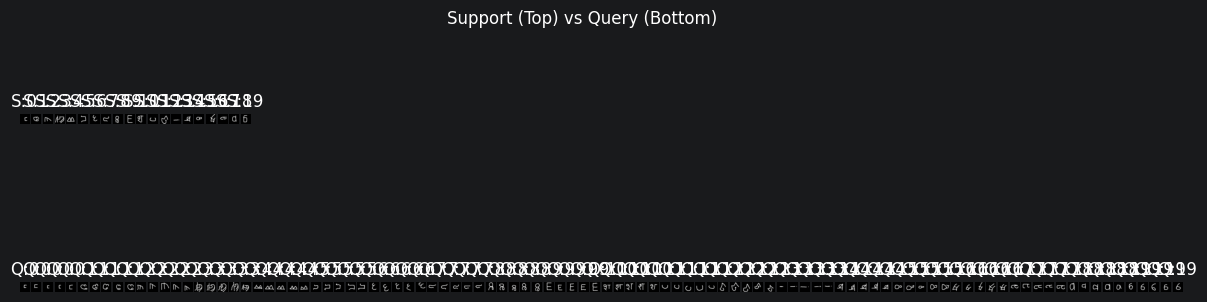

In [14]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=20,
    k_shot=1,
    q_query=5
)

visualize_task(support_x, support_y, query_x, query_y)

In [15]:
support_x, support_y, query_x, query_y = train_sampler.sample_task(
    n_way=20,
    k_shot=1,
    q_query=5
)

print("Support labels:", support_y)
print("Query labels:", query_y)
print("Unique support labels:", torch.unique(support_y))
print("Unique query labels:", torch.unique(query_y))

Support labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
Query labels: tensor([ 0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  3,
         3,  3,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  7,
         7,  7,  7,  7,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9, 10, 10, 10, 10,
        10, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 14, 14,
        14, 14, 14, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17,
        18, 18, 18, 18, 18, 19, 19, 19, 19, 19])
Unique support labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])
Unique query labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19])


In [16]:
print("Support label set:", set(support_y.tolist()))
print("Query label set:", set(query_y.tolist()))

Support label set: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
Query label set: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}


## Model

### OmniglotCNN

Four-block CNN matching the architecture from the OpenAI Reptile codebase.

```
Input [B, 1, 28, 28]
  → ConvBlock ×4  (Conv3×3 → BN → ReLU → MaxPool2×2)
  → [B, 64, 1, 1]
  → Linear(64, n_way)
  → logits [B, 20]
```

Each `ConvBlock` halves spatial resolution (28 → 14 → 7 → 3 → 1). `BatchNorm2d` is included; `track_running_stats=False` is left at default to keep the checkpoint architecture consistent.

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )
    def forward(self, x):
        return self.block(x)


class ResConvBlock(nn.Module):
    """Conv block with optional residual (same spatial size after pool)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.skip = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        ) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        out = self.relu(self.block(x) + self.skip(x))
        return self.pool(out)


class OmniglotCNN(nn.Module):
    """
    4-block CNN matching the OpenAI Reptile architecture.
    Input: [B, 1, 28, 28]  ->  feature: [B, 64, 1, 1]  ->  logits: [B, n_way]
    """
    def __init__(self, n_way, hidden=64):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,       hidden),
            ConvBlock(hidden,  hidden),
            ConvBlock(hidden,  hidden),
            ConvBlock(hidden,  hidden),
        )
        self.classifier = nn.Linear(hidden, n_way)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


### Inner-Loop Adaptation (`adapt_on_task`)

Deep-copies the meta-model and runs `inner_steps` of SGD on the support set. At meta-train time an additional `extra_x/extra_y` batch (from `train_shots=10`) is concatenated to the 1-shot support, implementing the train-shots trick. SGD is used instead of Adam to avoid momentum state bleeding across tasks.

In [18]:
criterion = nn.CrossEntropyLoss()

def adapt_on_task(meta_model, support_x, support_y, inner_lr=0.4, inner_steps=10,
                  extra_x=None, extra_y=None):
    """
    Fine-tune a copy of meta_model on a support set using SGD.

    extra_x/extra_y: additional training examples used only during meta-training
                     (train_shots trick from the OpenAI Reptile paper — using more
                     shots at train time than at eval time improves generalisation).
    """
    support_x = support_x.to(device)
    support_y = support_y.to(device)

    if extra_x is not None:
        support_x = torch.cat([support_x, extra_x.to(device)], dim=0)
        support_y = torch.cat([support_y, extra_y.to(device)], dim=0)

    task_model = copy.deepcopy(meta_model)
    task_model.train()


    optimizer = torch.optim.SGD(task_model.parameters(), lr=inner_lr, momentum=0.0)

    support_loss_value = None
    for _ in range(inner_steps):
        optimizer.zero_grad()
        logits = task_model(support_x)
        loss   = criterion(logits, support_y)
        loss.backward()
        optimizer.step()
        support_loss_value = loss.item()

    return task_model, support_loss_value


### Parameter Delta (`compute_task_delta`)

Returns the element-wise difference $W - \theta$ for every parameter tensor. Deltas are detached from the computation graph and accumulated across the meta-batch before the outer update.

In [19]:
def compute_task_delta(meta_model, task_model):
    return [
        (task_param - meta_param).detach()
        for meta_param, task_param in zip(meta_model.parameters(), task_model.parameters())
    ]

### Single-Task Evaluation (`evaluate_task`)

Adapts the meta-model on the support set (50 inner steps, matching the OpenAI eval protocol) then computes cross-entropy loss and accuracy on the query set under `torch.no_grad()`.

In [20]:
criterion = nn.CrossEntropyLoss()

def evaluate_task(meta_model, support_x, support_y, query_x, query_y,
                  inner_lr=0.4, inner_steps=50):
    """
    Evaluate one task.  Uses more inner steps at eval time (50) than training
    time (10) — matches the OpenAI Reptile evaluation protocol.
    """
    support_x = support_x.to(device)
    support_y = support_y.to(device)
    query_x   = query_x.to(device)
    query_y   = query_y.to(device)

    task_model, _ = adapt_on_task(
        meta_model=meta_model,
        support_x=support_x,
        support_y=support_y,
        inner_lr=inner_lr,
        inner_steps=inner_steps
    )

    task_model.eval()
    with torch.no_grad():
        query_logits = task_model(query_x)
        query_loss   = criterion(query_logits, query_y).item()
        query_preds  = query_logits.argmax(dim=1)
        query_acc    = (query_preds == query_y).float().mean().item()

    return query_loss, query_acc


### Multi-Task Evaluation (`evaluate_many_tasks`)

Aggregates `evaluate_task` over `num_tasks` randomly sampled episodes and returns mean query loss and mean query accuracy. Used for validation checkpointing (200 tasks) and final test reporting (1 000 tasks).

In [21]:
def evaluate_many_tasks(
    meta_model,
    test_sampler,
    num_tasks=200,
    n_way=20,
    k_shot=1,
    q_query=15,
    inner_lr=0.4,
    inner_steps=50
):
    """Evaluate the meta-model over many randomly sampled tasks."""
    meta_model.eval()
    all_losses, all_accs = [], []

    for _ in range(num_tasks):
        support_x, support_y, query_x, query_y = test_sampler.sample_task(
            n_way=n_way, k_shot=k_shot, q_query=q_query
        )
        loss, acc = evaluate_task(
            meta_model=meta_model,
            support_x=support_x,
            support_y=support_y,
            query_x=query_x,
            query_y=query_y,
            inner_lr=inner_lr,
            inner_steps=inner_steps
        )
        all_losses.append(loss)
        all_accs.append(acc)

    return sum(all_losses)/len(all_losses), sum(all_accs)/len(all_accs)


### Meta-Training Loop (`reptile_train`)

Per meta-iteration:

1. Sample `tasks_per_meta_batch` (5) episodes with `train_shots=10` support images.  
2. Adapt each task; accumulate parameter deltas $\sum_i (W_i - \theta)$.  
3. Apply the averaged update, scaled by the cosine-annealed meta-LR $\varepsilon_t$:
$$\theta \leftarrow \theta + \varepsilon_t \cdot \frac{1}{T}\sum_{i=1}^{T}(W_i - \theta)$$

Validation accuracy is computed every 1 000 iterations over 200 tasks (1-shot, 15-query). The best checkpoint is saved and restored at the end of training.

In [22]:
def reptile_train(
    meta_model,
    train_sampler,
    val_sampler=None,
    meta_iters=100000,
    tasks_per_meta_batch=5,
    inner_lr=0.4,
    inner_steps=10,
    meta_lr=1.0,
    meta_lr_final=0.0,
    train_shots=10,
    eval_every=1000,
    eval_tasks=200,
    eval_inner_steps=50,
    device="cuda",
    start_iter=1,
    history=None
):
    """
    Reptile meta-training with OpenAI-paper hyperparameters.

    Key design choices
    ------------------
    * SGD inner-loop  — no Adam momentum bleeding across tasks
    * inner_lr=0.4    — large inner LR is critical for Reptile
    * train_shots=10  — use 10 support examples per class during meta-training
                        even though eval uses k_shot=1; this is the 'train_shots'
                        trick from the OpenAI repo that significantly boosts accuracy
    * meta_lr cosine-annealed from 1.0 to 0 over the run
    * 5 tasks per meta-batch, average their parameter deltas
    """
    meta_model = meta_model.to(device)

    if history is None:
        history = {
            "train_support_losses":  [],
            "eval_query_losses":     [],
            "eval_query_accuracies": [],
            "best_eval_acc":         -1.0,
        }

    best_eval_acc   = history.get("best_eval_acc", -1.0)
    best_model_state = copy.deepcopy(meta_model.state_dict())

    total_iters = start_iter + meta_iters - 1  # total span for cosine schedule

    for meta_iter in range(start_iter, start_iter + meta_iters):
        meta_model.train()

        delta_sum = [torch.zeros_like(p, device=device) for p in meta_model.parameters()]
        meta_batch_support_losses = []

        for _ in range(tasks_per_meta_batch):

            support_x, support_y, _, _ = train_sampler.sample_task(
                n_way=20, k_shot=train_shots, q_query=1
            )

            task_model, support_loss_value = adapt_on_task(
                meta_model=meta_model,
                support_x=support_x,
                support_y=support_y,
                inner_lr=inner_lr,
                inner_steps=inner_steps
            )

            meta_batch_support_losses.append(support_loss_value)

            with torch.no_grad():
                for d_sum, meta_p, task_p in zip(delta_sum, meta_model.parameters(), task_model.parameters()):
                    d_sum.add_(task_p - meta_p)

        # Cosine-anneal meta_lr from meta_lr → meta_lr_final
        frac = (meta_iter - start_iter) / max(meta_iters - 1, 1)
        current_meta_lr = meta_lr_final + 0.5 * (meta_lr - meta_lr_final) * (1 + math.cos(math.pi * frac))

        with torch.no_grad():
            for meta_p, d_sum in zip(meta_model.parameters(), delta_sum):
                meta_p.add_(current_meta_lr * (d_sum / tasks_per_meta_batch))

        avg_support_loss = sum(meta_batch_support_losses) / len(meta_batch_support_losses)
        history["train_support_losses"].append(avg_support_loss)

        if meta_iter % eval_every == 0:
            sampler = val_sampler if val_sampler is not None else train_sampler

            eval_query_loss, eval_query_acc = evaluate_many_tasks(
                meta_model=meta_model,
                test_sampler=sampler,
                num_tasks=eval_tasks,
                n_way=20,
                k_shot=1,
                q_query=15,
                inner_lr=inner_lr,
                inner_steps=eval_inner_steps
            )

            history["eval_query_losses"].append((meta_iter, eval_query_loss))
            history["eval_query_accuracies"].append((meta_iter, eval_query_acc))

            print(
                f"[{meta_iter:6d}/{start_iter + meta_iters - 1}] "
                f"support_loss={avg_support_loss:.4f} | "
                f"eval_loss={eval_query_loss:.4f} | "
                f"eval_acc={eval_query_acc*100:.2f}%  "
                f"(meta_lr={current_meta_lr:.4f})"
            )

            if eval_query_acc > best_eval_acc:
                best_eval_acc = eval_query_acc
                history["best_eval_acc"] = best_eval_acc
                best_model_state = copy.deepcopy(meta_model.state_dict())

                torch.save({
                    "meta_iter":        meta_iter,
                    "model_state_dict": best_model_state,
                    "history":          history,
                }, "reptile_best_checkpoint.pt")
                print(f"  ✓ New best: {best_eval_acc*100:.2f}% — checkpoint saved")

    meta_model.load_state_dict(best_model_state)
    return meta_model, history


In [23]:
import math

n_way      = 20
meta_model = OmniglotCNN(n_way=n_way)

LOAD_FROM_CHECKPOINT = True   # set False to train from scratch

if LOAD_FROM_CHECKPOINT and os.path.exists("reptile_best_checkpoint.pt"):
    checkpoint  = torch.load("reptile_best_checkpoint.pt", map_location=device)
    meta_model.load_state_dict(checkpoint["model_state_dict"])
    meta_model  = meta_model.to(device)
    start_iter  = checkpoint["meta_iter"] + 1
    history     = checkpoint["history"]
    print(f"Resumed from iter {checkpoint['meta_iter']}  "
          f"(best acc so far: {history['best_eval_acc']*100:.2f}%)")


    meta_model, history = reptile_train(
        meta_model=meta_model,
        train_sampler=train_sampler,
        val_sampler=val_sampler,
        meta_iters=26000,
        tasks_per_meta_batch=5,
        inner_lr=0.4,
        inner_steps=10,
        meta_lr=1.0,
        meta_lr_final=0.0,
        train_shots=10,
        eval_every=1000,
        eval_tasks=200,
        eval_inner_steps=50,
        device=device,
        start_iter=start_iter,
        history=history
    )

else:
    meta_model, history = reptile_train(
        meta_model=meta_model,
        train_sampler=train_sampler,
        val_sampler=val_sampler,
        meta_iters=100000,
        tasks_per_meta_batch=5,
        inner_lr=0.4,
        inner_steps=10,
        meta_lr=1.0,
        meta_lr_final=0.0,
        train_shots=10,
        eval_every=1000,
        eval_tasks=200,
        eval_inner_steps=50,
        device=device
    )


Resumed from iter 26000  (best acc so far: 89.58%)


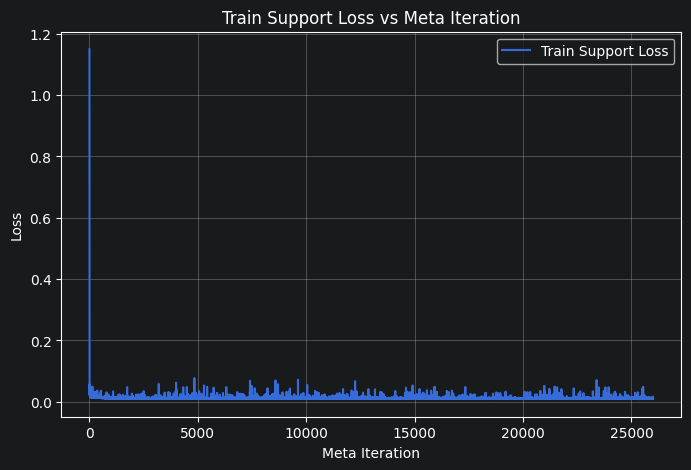

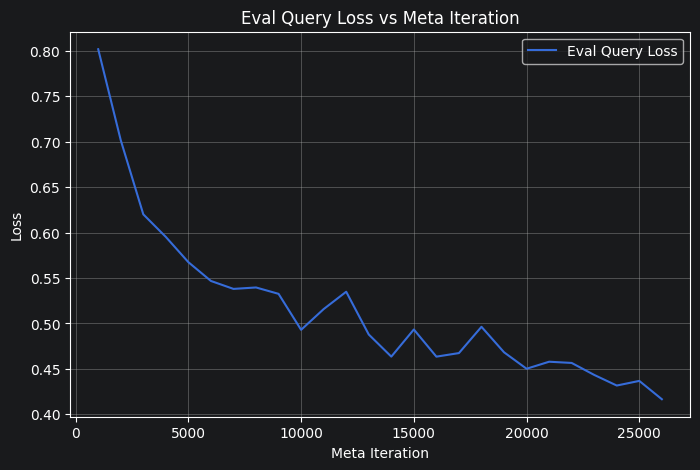

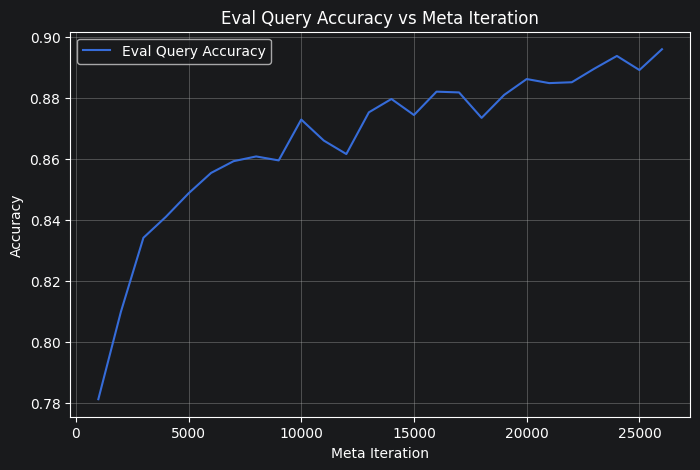

In [24]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_support_losses"]) + 1), history["train_support_losses"], label="Train Support Loss")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.title("Train Support Loss vs Meta Iteration")
plt.legend()
plt.grid(True)
plt.show()


eval_meta_iters_loss = [x[0] for x in history["eval_query_losses"]]
eval_losses = [x[1] for x in history["eval_query_losses"]]

plt.figure(figsize=(8, 5))
plt.plot(eval_meta_iters_loss, eval_losses, label="Eval Query Loss")
plt.xlabel("Meta Iteration")
plt.ylabel("Loss")
plt.title("Eval Query Loss vs Meta Iteration")
plt.legend()
plt.grid(True)
plt.show()


eval_meta_iters_acc = [x[0] for x in history["eval_query_accuracies"]]
eval_accs = [x[1] for x in history["eval_query_accuracies"]]

plt.figure(figsize=(8, 5))
plt.plot(eval_meta_iters_acc, eval_accs, label="Eval Query Accuracy")
plt.xlabel("Meta Iteration")
plt.ylabel("Accuracy")
plt.title("Eval Query Accuracy vs Meta Iteration")
plt.legend()
plt.grid(True)
plt.show()

In [25]:

avg_test_loss, avg_test_acc = evaluate_many_tasks(
    meta_model=meta_model,
    test_sampler=test_sampler,
    num_tasks=1000,
    n_way=20,
    k_shot=1,
    q_query=15,
    inner_lr=0.4,
    inner_steps=50
)

print(f"Test query loss:     {avg_test_loss:.4f}")
print(f"Test query accuracy: {avg_test_acc*100:.2f}%")


Test query loss:     0.5662
Test query accuracy: 85.27%
